# Complete 379-region TVB experiment

**Research question**

How does increasing AD-like amyloid-linked inhibitory dysfunction affect stimulus-evoked transmission from bilateral primary auditory cortex to music-associated versus speech-associated cortical proxy subnetworks?

This notebook runs the complete experiment on Google Colab. It uses:

- the public 379-region structural matrix used in the Stefanovski educational model;
- the matching 379-label Glasser plus subcortical parcel order from the BrainModes ADNI-TVB pipeline;
- the published Stefanovski amyloid-to-inhibitory-rate transformation;
- baseline, intermediate, and high AD-like perturbation strengths;
- identical pulse, 2 Hz, and 5 Hz probes delivered to bilateral A1;
- matched unstimulated simulations;
- full-field and local-dynamics-held-baseline analyses;
- topology/pathology-matched control subnetworks;
- coupling, stimulus-strength, spatial-placement, and integration-step checks.

**Central interpretation boundary:** this is a mechanistic simulation of one AD-related process. It is not a clinical HC/MCI/AD comparison, a model of disease progression, or a test of preserved musical memory.

## 1. What this experiment can and cannot establish

The public amyloid endpoint is an artificial surrogate constructed from noise and selected properties of ADNI-derived data. The intermediate condition is exactly halfway between the baseline and high endpoint in the model parameter \(b\). It is not an MCI brain.

The experiment can test whether the two predeclared cortical proxy subnetworks respond differently inside this specific amyloid-linked inhibitory model. It cannot establish that either network is clinically preserved in people with Alzheimer’s disease.

The target definitions are deliberately small, bilateral, and equal in size:

- **Music-associated proxy:** area 6ma and area 24dd, used as parcel-level approximations of ventral pre-SMA and caudal/anterior cingulate targets implicated in long-known musical memory.
- **Speech-associated proxy:** STSdp and area 44, used as parcel-level approximations of posterior superior temporal and inferior-frontal speech targets.

These are proxy subnetworks, not complete or exclusive music and speech pathways. The 2 Hz and 5 Hz inputs are temporal-envelope probes, not literal music and speech recordings.

## 2. Colab setup

The installation is version-pinned for reproducibility. Colab normally already includes NumPy, pandas, Matplotlib, and SciPy.

In [2]:
import importlib.util
import subprocess
import sys

required = {
    "tvb": ("tvb-library==2.10.0", "tvb-data==3.0.0"),
    "pandas": ("pandas>=2.0",),
    "matplotlib": ("matplotlib>=3.7",),
    "scipy": ("scipy>=1.10",),
}

missing_specs = []
for import_name, specs in required.items():
    if importlib.util.find_spec(import_name) is None:
        missing_specs.extend(specs)

if missing_specs:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_specs]
    )
else:
    print("Required packages are already available.")

In [3]:
import gc
import hashlib
import json
import math
import os
import platform
import shutil
import time
import urllib.request
import warnings
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("TVB_USER_HOME", "/tmp/rise_tvb_user")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/rise_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
import tvb
from tvb.simulator.lab import (
    connectivity,
    coupling,
    equations,
    integrators,
    models,
    monitors,
    patterns,
    simulator,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

IS_COLAB = "google.colab" in sys.modules
WORK_DIR = (
    Path("/content/rise_tvb379")
    if IS_COLAB
    else Path.cwd() / "rise_tvb379_work"
)
DATA_DIR = WORK_DIR / "source_data"
WORK_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(
    {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "tvb": getattr(tvb, "__version__", "unknown"),
        "colab": IS_COLAB,
        "work_dir": str(WORK_DIR),
    }
)

class SimpleProgress:
    def __init__(self, total, description):
        self.total = int(total)
        self.description = str(description)
        self.count = 0
        self.report_every = max(1, self.total // 10)
        print(f"{self.description}: 0/{self.total}")

    def update(self, amount=1):
        self.count += int(amount)
        if self.count == self.total or self.count % self.report_every == 0:
            print(f"{self.description}: {self.count}/{self.total}")

    def close(self):
        if self.count != self.total:
            print(f"{self.description}: stopped at {self.count}/{self.total}")

def progress_iter(values, description):
    values = list(values)
    progress = SimpleProgress(len(values), description)
    for value in values:
        yield value
        progress.update()
    progress.close()

/usr/local/lib/python3.12/dist-packages/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


{'python': '3.12.13', 'numpy': '2.0.2', 'pandas': '2.2.2', 'scipy': '1.16.3', 'tvb': 'unknown', 'colab': True, 'work_dir': '/content/rise_tvb379'}


## 3. Run configuration

`final` is the default and runs the full experiment. For an initial technical check, change it to `pilot`. The `smoke` mode exists for automated notebook validation and is not adequate for scientific interpretation.

Numerical seeds test sensitivity to initial conditions. They are repeated model runs, not participants or independent biological samples.

In [4]:
RUN_MODE = os.environ.get("RISE_RUN_MODE", "final").strip().lower()
if RUN_MODE not in {"smoke", "pilot", "final"}:
    raise ValueError("RUN_MODE must be 'smoke', 'pilot', or 'final'.")

MODE_CONFIG = {
    "smoke": {
        "seeds": [11],
        "severities": [0.0, 1.0],
        "calibration_couplings": [60.0],
        "matched_null_sets": 40,
        "spatial_shuffles": 1,
        "sensitivity_scenarios": [
            {"scenario": "G30", "global_coupling": 30.0, "input_peak": 0.02}
        ],
    },
    "pilot": {
        "seeds": [11, 23],
        "severities": [0.0, 0.5, 1.0],
        "calibration_couplings": [30.0, 60.0, 100.0],
        "matched_null_sets": 200,
        "spatial_shuffles": 2,
        "sensitivity_scenarios": [
            {"scenario": "G30", "global_coupling": 30.0, "input_peak": 0.02},
            {"scenario": "G100", "global_coupling": 100.0, "input_peak": 0.02},
        ],
    },
    "final": {
        "seeds": [11, 23, 37, 53, 71],
        "severities": [0.0, 0.5, 1.0],
        "calibration_couplings": [10.0, 30.0, 60.0, 100.0, 200.0, 300.0],
        "matched_null_sets": 500,
        "spatial_shuffles": 100,
        "sensitivity_scenarios": [
            {"scenario": "G30", "global_coupling": 30.0, "input_peak": 0.02},
            {"scenario": "G100", "global_coupling": 100.0, "input_peak": 0.02},
            {"scenario": "input_0.01", "global_coupling": 60.0, "input_peak": 0.01},
            {"scenario": "input_0.04", "global_coupling": 60.0, "input_peak": 0.04},
        ],
    },
}
CFG = MODE_CONFIG[RUN_MODE]

N_REGIONS = 379
MAIN_GLOBAL_COUPLING = 60.0
MAIN_INPUT_PEAK_PER_MS = 0.02
MAIN_DT_MS = 1.0
REFERENCE_DT_MS = 0.5
MONITOR_PERIOD_MS = 2.0

STIMULUS_ONSET_MS = 2500.0
SIMULATION_MS = 6500.0
PERIODIC_ANALYSIS_START_MS = 3500.0
PULSE_WIDTH_MS = 100.0
PULSE_ANALYSIS_END_MS = 3500.0

PROBES = ("pulse", "2Hz", "5Hz")
PERIODIC_PROBES = ("2Hz", "5Hz")
SEVERITY_LABELS = {
    0.0: "Baseline",
    0.5: "Intermediate AD-like perturbation",
    1.0: "High AD-like perturbation",
}
DOWNLOAD_RESULTS_AT_END = False

RESULTS_DIR = WORK_DIR / f"results_{RUN_MODE}"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_MODE:", RUN_MODE)
print("Numerical seeds:", CFG["seeds"])
print("Main severities:", CFG["severities"])
print("Results directory:", RESULTS_DIR)

RUN_MODE: final
Numerical seeds: [11, 23, 37, 53, 71]
Main severities: [0.0, 0.5, 1.0]
Results directory: /content/rise_tvb379/results_final


## 4. Download pinned source files and verify their hashes

Every required file is pinned to a specific Git commit and checked against a known SHA-256 hash. A failed hash check stops the notebook rather than silently running with a different matrix or label order.

In [5]:
EDUCASE_COMMIT = "659d4fcbf58d74867fa9d10a874deac854532ee1"
PIPELINE_COMMIT = "8be09e33e1131ed2f0764506940e6172de275285"

SOURCE_SPECS = {
    "structural_connectivity": {
        "filename": "avg_healthy_normSC_mod.txt",
        "url": (
            "https://raw.githubusercontent.com/BrainModes/"
            "TVB_EducaseAD_molecular_pathways_TVB/"
            f"{EDUCASE_COMMIT}/avg_healthy_normSC_mod.txt"
        ),
        "sha256": "141fc993c84bde0b2f0ee0280ce1ccc47e1731ddcbf37845a4eef38dad9fa562",
    },
    "ad_left_cortex": {
        "filename": "AD_LH.txt",
        "url": (
            "https://raw.githubusercontent.com/BrainModes/"
            "TVB_EducaseAD_molecular_pathways_TVB/"
            f"{EDUCASE_COMMIT}/_AD/AD_LH.txt"
        ),
        "sha256": "566e770e93f50d3378a0cf7d2dc8b1fa5af9475ca432463acf7bc2b5507907af",
    },
    "ad_right_cortex": {
        "filename": "AD_RH.txt",
        "url": (
            "https://raw.githubusercontent.com/BrainModes/"
            "TVB_EducaseAD_molecular_pathways_TVB/"
            f"{EDUCASE_COMMIT}/_AD/AD_RH.txt"
        ),
        "sha256": "4f42c31c08e6d191d415953f763889f816d9c2443d115612f0c076cfd5b2f129",
    },
    "ad_subcortical": {
        "filename": "AD_subcortical.txt",
        "url": (
            "https://raw.githubusercontent.com/BrainModes/"
            "TVB_EducaseAD_molecular_pathways_TVB/"
            f"{EDUCASE_COMMIT}/_AD/AD_subcortical.txt"
        ),
        "sha256": "f28926c7955db2c2762b5ba032f0bbde770a0da3d3705dd037a746382506d824",
    },
    "region_labels": {
        "filename": "region_labels.txt",
        "url": (
            "https://raw.githubusercontent.com/BrainModes/"
            f"ADNI-TVB-pipeline/{PIPELINE_COMMIT}/misc_files/region_labels.txt"
        ),
        "sha256": "f9688592130a034210b482a0556fdc14383eaaf578bef39d2ddba072537e3484",
    },
}

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def fetch_verified(name, spec):
    destination = DATA_DIR / spec["filename"]
    local_cache = os.environ.get("RISE_DATA_CACHE")
    cache_candidate = (
        Path(local_cache) / spec["filename"] if local_cache else None
    )

    if destination.exists() and sha256_file(destination) == spec["sha256"]:
        source_used = "existing verified file"
    elif (
        cache_candidate is not None
        and cache_candidate.exists()
        and sha256_file(cache_candidate) == spec["sha256"]
    ):
        shutil.copyfile(cache_candidate, destination)
        source_used = "verified local validation cache"
    else:
        print(f"Downloading {name}...")
        with urllib.request.urlopen(spec["url"], timeout=120) as response:
            destination.write_bytes(response.read())
        source_used = spec["url"]

    actual = sha256_file(destination)
    if actual != spec["sha256"]:
        raise RuntimeError(
            f"SHA-256 mismatch for {name}. Expected {spec['sha256']}, got {actual}."
        )
    return {
        "source": name,
        "path": str(destination),
        "sha256": actual,
        "retrieved_from": source_used,
    }

source_manifest_df = pd.DataFrame(
    [fetch_verified(name, spec) for name, spec in SOURCE_SPECS.items()]
)
display(source_manifest_df)

,source,path,sha256,retrieved_from
0,structural_connectivity,/content/rise_tvb379/source_data/avg_healthy_n...,141fc993c84bde0b2f0ee0280ce1ccc47e1731ddcbf378...,https://raw.githubusercontent.com/BrainModes/T...
1,ad_left_cortex,/content/rise_tvb379/source_data/AD_LH.txt,566e770e93f50d3378a0cf7d2dc8b1fa5af9475ca43246...,https://raw.githubusercontent.com/BrainModes/T...
2,ad_right_cortex,/content/rise_tvb379/source_data/AD_RH.txt,4f42c31c08e6d191d415953f763889f816d9c2443d1156...,https://raw.githubusercontent.com/BrainModes/T...
3,ad_subcortical,/content/rise_tvb379/source_data/AD_subcortica...,f28926c7955db2c2762b5ba032f0bbde770a0da3d3705d...,https://raw.githubusercontent.com/BrainModes/T...
4,region_labels,/content/rise_tvb379/source_data/region_labels...,f9688592130a034210b482a0556fdc14383eaaf578bef3...,https://raw.githubusercontent.com/BrainModes/A...


## 5. Load and validate the 379-region alignment

These checks are scientific safeguards, not cosmetic tests. The amyloid vector, structural matrix, and parcel labels must have the exact same order. The structural matrix is intentionally left in its published form. It is not symmetrized or renormalized for simulation.

In [6]:
WEIGHTS = np.loadtxt(DATA_DIR / SOURCE_SPECS["structural_connectivity"]["filename"])
LABELS = np.array(
    [
        line.strip()
        for line in (
            DATA_DIR / SOURCE_SPECS["region_labels"]["filename"]
        ).read_text().splitlines()
        if line.strip()
    ]
)
AD_AMYLOID = np.concatenate(
    [
        np.loadtxt(DATA_DIR / SOURCE_SPECS["ad_left_cortex"]["filename"]),
        np.loadtxt(DATA_DIR / SOURCE_SPECS["ad_right_cortex"]["filename"]),
        np.loadtxt(DATA_DIR / SOURCE_SPECS["ad_subcortical"]["filename"]),
    ]
)

hard_checks = {
    "SC is 379 x 379": WEIGHTS.shape == (N_REGIONS, N_REGIONS),
    "379 unique labels": len(LABELS) == N_REGIONS
    and len(set(LABELS.tolist())) == N_REGIONS,
    "379 amyloid values": AD_AMYLOID.shape == (N_REGIONS,),
    "SC values finite": np.isfinite(WEIGHTS).all(),
    "SC values nonnegative": (WEIGHTS >= 0).all(),
    "amyloid values finite": np.isfinite(AD_AMYLOID).all(),
    "left cortex occupies 0:180": all(
        label.startswith("L_") for label in LABELS[:180]
    ),
    "right cortex occupies 180:360": all(
        label.startswith("R_") for label in LABELS[180:360]
    ),
    "brainstem is final parcel": LABELS[-1] == "Brainstem",
}
failed_checks = [name for name, passed in hard_checks.items() if not passed]
if failed_checks:
    raise RuntimeError("Input validation failed: " + "; ".join(failed_checks))

LABEL_TO_INDEX = {label: index for index, label in enumerate(LABELS)}
expected_anchors = {
    "L_A1": 23,
    "R_A1": 203,
    "L_6ma": 43,
    "R_6ma": 223,
    "L_24dd": 39,
    "R_24dd": 219,
    "L_STSdp": 128,
    "R_STSdp": 308,
    "L_44": 73,
    "R_44": 253,
}
anchor_failures = {
    label: (LABEL_TO_INDEX.get(label), expected_index)
    for label, expected_index in expected_anchors.items()
    if LABEL_TO_INDEX.get(label) != expected_index
}
if anchor_failures:
    raise RuntimeError(f"Parcel-order anchor check failed: {anchor_failures}")

relative_asymmetry = float(
    np.linalg.norm(WEIGHTS - WEIGHTS.T) / np.linalg.norm(WEIGHTS)
)
data_quality_df = pd.DataFrame(
    {
        "check": list(hard_checks.keys())
        + [
            "SC minimum",
            "SC maximum",
            "SC relative asymmetry",
            "amyloid minimum",
            "amyloid maximum",
            "amyloid mean",
        ],
        "result": list(hard_checks.values())
        + [
            float(WEIGHTS.min()),
            float(WEIGHTS.max()),
            relative_asymmetry,
            float(AD_AMYLOID.min()),
            float(AD_AMYLOID.max()),
            float(AD_AMYLOID.mean()),
        ],
    }
)
display(data_quality_df)
print(
    "The nonzero asymmetry is a property of the published matrix. "
    "The simulation preserves it."
)

,check,result
0,SC is 379 x 379,True
1,379 unique labels,True
2,379 amyloid values,True
3,SC values finite,True
4,SC values nonnegative,True
5,amyloid values finite,True
6,left cortex occupies 0:180,True
7,right cortex occupies 180:360,True
8,brainstem is final parcel,True
9,SC minimum,0.0


The nonzero asymmetry is a property of the published matrix. The simulation preserves it.


## 6. Predeclare the stimulation and target parcels

The parcel selections are fixed before running the disease perturbation. Both target groups contain four bilateral cortical parcels.

In [ ]:
A1_LABELS = ("L_A1", "R_A1")
MUSIC_LABELS = ("L_6ma", "R_6ma", "L_24dd", "R_24dd")
SPEECH_LABELS = ("L_STSdp", "R_STSdp", "L_44", "R_44")

A1_INDICES = np.array([LABEL_TO_INDEX[label] for label in A1_LABELS])
MUSIC_INDICES = np.array([LABEL_TO_INDEX[label] for label in MUSIC_LABELS])
SPEECH_INDICES = np.array([LABEL_TO_INDEX[label] for label in SPEECH_LABELS])
ALL_DECLARED_INDICES = np.concatenate(
    [A1_INDICES, MUSIC_INDICES, SPEECH_INDICES]
)

if len(MUSIC_INDICES) != len(SPEECH_INDICES):
    raise RuntimeError("Music and speech proxy groups must have equal size.")
if len(np.unique(ALL_DECLARED_INDICES)) != len(ALL_DECLARED_INDICES):
    raise RuntimeError("A parcel appears in more than one predeclared group.")

roi_rows = []
for network, labels, interpretation in [
    (
        "A1 seed",
        A1_LABELS,
        "bilateral primary auditory cortex stimulation",
    ),
    (
        "Music proxy",
        MUSIC_LABELS,
        "parcel approximations of ventral pre-SMA and caudal/anterior cingulate targets",
    ),
    (
        "Speech proxy",
        SPEECH_LABELS,
        "parcel approximations of posterior STS and inferior-frontal targets",
    ),
]:
    for label in labels:
        roi_rows.append(
            {
                "network": network,
                "label": label,
                "zero_based_index": LABEL_TO_INDEX[label],
                "interpretation": interpretation,
            }
        )
roi_definition_df = pd.DataFrame(roi_rows)
display(roi_definition_df)

,network,label,zero_based_index,interpretation
0,A1 seed,L_A1,23,bilateral primary auditory cortex stimulation
1,A1 seed,R_A1,203,bilateral primary auditory cortex stimulation
2,Music proxy,L_6ma,43,parcel approximations of ventral pre-SMA and c...
3,Music proxy,R_6ma,223,parcel approximations of ventral pre-SMA and c...
4,Music proxy,L_24dd,39,parcel approximations of ventral pre-SMA and c...
5,Music proxy,R_24dd,219,parcel approximations of ventral pre-SMA and c...
6,Speech proxy,L_STSdp,128,parcel approximations of posterior STS and inf...
7,Speech proxy,R_STSdp,308,parcel approximations of posterior STS and inf...
8,Speech proxy,L_44,73,parcel approximations of posterior STS and inf...
9,Speech proxy,R_44,253,parcel approximations of posterior STS and inf...


## 7. Construct the AD-like inhibitory perturbation

Stefanovski et al. mapped regional amyloid burden to the Jansen-Rit inhibitory rate \(b=1/\tau_i\). The same published sigmoid is used here.

- **Baseline:** \(b=0.07\) at every parcel.
- **Intermediate AD-like perturbation:** halfway from baseline to the transformed high endpoint in \(b\)-space.
- **High AD-like perturbation:** the full transformed public AD surrogate vector.

The intermediate value is an experimental perturbation level. It is not labeled MCI.

In [ ]:
def transform_amyloid_to_b(
    amyloid,
    max_val=0.05,
    min_val=0.02,
    amyloid_max=2.65,
    amyloid_offset=1.4,
):
    amyloid = np.asarray(amyloid, dtype=float)
    x0 = (amyloid_max - amyloid_offset) / 2.0 + amyloid_offset
    k = (
        np.log(max_val / ((min_val + 0.001) - min_val) - 1.0)
        / (amyloid_max - x0)
    )
    return max_val / (1.0 + np.exp(k * (amyloid - x0))) + min_val

BASELINE_B = np.full(N_REGIONS, 0.07, dtype=float)
HIGH_B = transform_amyloid_to_b(AD_AMYLOID)
B_BY_SEVERITY = {
    severity: BASELINE_B + severity * (HIGH_B - BASELINE_B)
    for severity in (0.0, 0.5, 1.0)
}

if not np.isfinite(HIGH_B).all():
    raise RuntimeError("The transformed inhibitory vector contains nonfinite values.")
if HIGH_B.min() < 0.0199 or HIGH_B.max() > 0.0701:
    raise RuntimeError("The transformed inhibitory vector is outside the expected range.")

pathology_summary_df = pd.DataFrame(
    [
        {
            "severity": severity,
            "condition": SEVERITY_LABELS[severity],
            "b_min": float(values.min()),
            "b_mean": float(values.mean()),
            "b_max": float(values.max()),
            "mean_tau_i_ms": float(np.mean(1.0 / values)),
        }
        for severity, values in B_BY_SEVERITY.items()
    ]
)
display(pathology_summary_df)

roi_pathology_df = roi_definition_df.copy()
roi_pathology_df["surrogate_amyloid"] = [
    AD_AMYLOID[LABEL_TO_INDEX[label]]
    for label in roi_pathology_df["label"]
]
roi_pathology_df["baseline_b"] = 0.07
roi_pathology_df["high_b"] = [
    HIGH_B[LABEL_TO_INDEX[label]] for label in roi_pathology_df["label"]
]
roi_pathology_df["b_reduction"] = (
    roi_pathology_df["baseline_b"] - roi_pathology_df["high_b"]
)
display(roi_pathology_df)
print(
    "Important: the target parcels have different local surrogate amyloid values. "
    "The local-dynamics-held-baseline counterfactual later in the notebook is therefore required."
)

,severity,condition,b_min,b_mean,b_max,mean_tau_i_ms
0,0.0,Baseline,0.070000,0.070000,0.070000,14.285714
1,0.5,Intermediate AD-like perturbation,0.045000,0.061484,0.069863,16.552754
2,1.0,High AD-like perturbation,0.020001,0.052969,0.069725,21.513043


,network,label,zero_based_index,interpretation,surrogate_amyloid,baseline_b,high_b,b_reduction
0,A1 seed,L_A1,23,bilateral primary auditory cortex stimulation,1.693470,0.07,0.064370,0.005630
1,A1 seed,R_A1,203,bilateral primary auditory cortex stimulation,1.743497,0.07,0.062616,0.007384
2,Music proxy,L_6ma,43,parcel approximations of ventral pre-SMA and c...,1.879601,0.07,0.055603,0.014397
3,Music proxy,R_6ma,223,parcel approximations of ventral pre-SMA and c...,2.084658,0.07,0.040409,0.029591
4,Music proxy,L_24dd,39,parcel approximations of ventral pre-SMA and c...,1.805740,0.07,0.059831,0.010169
5,Music proxy,R_24dd,219,parcel approximations of ventral pre-SMA and c...,2.776230,0.07,0.020461,0.049539
6,Speech proxy,L_STSdp,128,parcel approximations of posterior STS and inf...,1.778658,0.07,0.061129,0.008871
7,Speech proxy,R_STSdp,308,parcel approximations of posterior STS and inf...,1.660995,0.07,0.065304,0.004696
8,Speech proxy,L_44,73,parcel approximations of posterior STS and inf...,1.491518,0.07,0.068259,0.001741
9,Speech proxy,R_44,253,parcel approximations of posterior STS and inf...,1.972138,0.07,0.049078,0.020922


Important: the target parcels have different local surrogate amyloid values. The local-dynamics-held-baseline counterfactual later in the notebook is therefore required.


## 8. TVB model and stimulus functions

The structural matrix, Jansen-Rit settings, zero-delay assumption, and amyloid transformation follow the public Stefanovski educational model. The original companion notebook used a 0.5 ms integration step. This notebook uses 1.0 ms after a required convergence check later in the workflow.

TVB adds a regional stimulus directly to a state derivative. The requested extra external-input rate is therefore multiplied by \(A a\) before it is injected into state variable `y4`. This makes `input_peak=0.02` correspond to an added Jansen-Rit external input of 0.02 per ms.

In [ ]:
def fresh_connectivity():
    return connectivity.Connectivity(
        weights=WEIGHTS.copy(),
        tract_lengths=np.zeros_like(WEIGHTS),
        centres=np.zeros((N_REGIONS, 3), dtype=float),
        region_labels=LABELS.copy(),
        speed=np.array([100.0]),
    )

def build_model(b_values):
    background = np.array([0.1085])
    model = models.JansenRit(
        v0=np.array([6.0]),
        mu=background,
        p_min=background,
        p_max=background,
        b=np.asarray(b_values, dtype=float),
        variables_of_interest=("y1", "y2"),
    )
    # External input p(t) enters the y4 derivative in TVB's Jansen-Rit model.
    model.stvar = np.array([4], dtype=np.int32)
    return model

def make_temporal_equation(
    probe,
    model,
    input_peak_per_ms,
    onset_ms=STIMULUS_ONSET_MS,
    offset_ms=SIMULATION_MS,
):
    derivative_peak = float(
        model.A[0] * model.a[0] * float(input_peak_per_ms)
    )
    if probe == "pulse":
        return equations.TemporalApplicableEquation(
            equation=(
                "where((var >= onset) & (var < onset + width), amp, 0.0)"
            ),
            parameters={
                "onset": float(onset_ms),
                "width": float(PULSE_WIDTH_MS),
                "amp": derivative_peak,
            },
        )

    frequency_per_ms = {"2Hz": 0.002, "5Hz": 0.005}[probe]
    return equations.TemporalApplicableEquation(
        equation=(
            "where((var >= onset) & (var <= offset), "
            "0.5 * amp * (1.0 + sin(6.283185307179586 * "
            "frequency * (var - onset))), 0.0)"
        ),
        parameters={
            "onset": float(onset_ms),
            "offset": float(offset_ms),
            "amp": derivative_peak,
            "frequency": frequency_per_ms,
        },
    )

def make_initial_conditions(seed, dt_ms):
    rng = np.random.default_rng(int(seed))
    # Zero delays require only one state-history sample.
    return rng.random((1, 6, N_REGIONS, 1))

def run_tvb(
    b_values,
    probe,
    global_coupling,
    input_peak_per_ms,
    seed,
    dt_ms=MAIN_DT_MS,
    simulation_ms=SIMULATION_MS,
):
    b_values = np.asarray(b_values, dtype=float)
    if b_values.shape != (N_REGIONS,) or not np.isfinite(b_values).all():
        raise ValueError("b_values must be a finite 379-element vector.")
    if probe not in {None, "pulse", "2Hz", "5Hz"}:
        raise ValueError(f"Unknown probe: {probe}")
    if MONITOR_PERIOD_MS % float(dt_ms) != 0:
        raise ValueError("Monitor period must be an integer multiple of dt.")

    white_matter = fresh_connectivity()
    model = build_model(b_values)
    stimulus = None
    if probe is not None:
        regional_weights = np.zeros(N_REGIONS, dtype=float)
        regional_weights[A1_INDICES] = 1.0 / np.sqrt(len(A1_INDICES))
        stimulus = patterns.StimuliRegion(
            temporal=make_temporal_equation(
                probe,
                model,
                input_peak_per_ms,
                offset_ms=simulation_ms,
            ),
            connectivity=white_matter,
            weight=regional_weights,
        )

    experiment = simulator.Simulator(
        connectivity=white_matter,
        model=model,
        coupling=coupling.SigmoidalJansenRit(
            a=np.array([float(global_coupling)])
        ),
        integrator=integrators.HeunDeterministic(dt=float(dt_ms)),
        monitors=(monitors.SubSample(period=MONITOR_PERIOD_MS),),
        stimulus=stimulus,
        initial_conditions=make_initial_conditions(seed, dt_ms),
    )
    experiment.configure()

    started = time.perf_counter()
    (time_ms, raw), = experiment.run(simulation_length=float(simulation_ms))
    wall_seconds = time.perf_counter() - started
    psp = raw[:, 0, :, 0] - raw[:, 1, :, 0]
    time_ms = np.asarray(time_ms, dtype=float)
    psp = np.asarray(psp, dtype=float)

    if psp.shape[1] != N_REGIONS:
        raise RuntimeError(f"Unexpected TVB output shape: {psp.shape}")
    if not np.isfinite(psp).all():
        raise RuntimeError("TVB produced NaN or infinite values.")
    if float(np.max(np.abs(psp))) > 100.0:
        raise RuntimeError(
            "TVB activity exceeded the prespecified safety bound of 100."
        )
    return time_ms, psp, wall_seconds

## 9. Response metrics and experiment runner

The primary response for 2 Hz and 5 Hz is the fitted harmonic amplitude at the exact drive frequency. A sine, cosine, intercept, and linear trend are fitted to the last 3 seconds of the control-subtracted response.

For each target network:

\[
\text{transfer} =
\frac{\text{mean target harmonic amplitude}}
     {\text{mean bilateral A1 harmonic amplitude}}
\]

Each network is then normalized to its own baseline using a log-ratio. The primary contrast is:

\[
\Delta = \log_2(\text{music transfer}/\text{music baseline})
- \log_2(\text{speech transfer}/\text{speech baseline})
\]

Positive \(\Delta\) means the music proxy changed more favorably than the speech proxy within this model. It does not demonstrate preserved musical memory.

The pulse response is a secondary RMS propagation diagnostic. Ordinary coherence and raw correlation are intentionally excluded because deterministic sinusoidal forcing can saturate them near 1.0.

In [ ]:
NETWORK_INDICES = {
    "music": MUSIC_INDICES,
    "speech": SPEECH_INDICES,
}

def harmonic_amplitude(time_ms, evoked, probe):
    frequency_hz = {"2Hz": 2.0, "5Hz": 5.0}[probe]
    window = (
        (time_ms >= PERIODIC_ANALYSIS_START_MS)
        & (time_ms <= SIMULATION_MS)
    )
    t_seconds = (time_ms[window] - PERIODIC_ANALYSIS_START_MS) / 1000.0
    y = np.asarray(evoked[window], dtype=float)
    if len(t_seconds) < 100:
        raise RuntimeError("Periodic analysis window is unexpectedly short.")

    omega_t = 2.0 * np.pi * frequency_hz * t_seconds
    design = np.column_stack(
        [
            np.sin(omega_t),
            np.cos(omega_t),
            np.ones_like(t_seconds),
            t_seconds - np.mean(t_seconds),
        ]
    )
    coefficients, _, _, _ = np.linalg.lstsq(design, y, rcond=None)
    fitted = design @ coefficients
    amplitude = np.sqrt(coefficients[0] ** 2 + coefficients[1] ** 2)

    residual_ss = np.sum((y - fitted) ** 2, axis=0)
    total_ss = np.sum((y - np.mean(y, axis=0)) ** 2, axis=0)
    r_squared = 1.0 - residual_ss / np.maximum(total_ss, 1e-15)
    return amplitude, r_squared

def pulse_rms(time_ms, evoked):
    window = (
        (time_ms >= STIMULUS_ONSET_MS)
        & (time_ms <= PULSE_ANALYSIS_END_MS)
    )
    y = np.asarray(evoked[window], dtype=float)
    if y.shape[0] < 100:
        raise RuntimeError("Pulse analysis window is unexpectedly short.")
    response = np.sqrt(np.mean(y ** 2, axis=0))
    return response, np.full(N_REGIONS, np.nan)

def extract_node_response(time_ms, evoked, probe):
    if probe == "pulse":
        return pulse_rms(time_ms, evoked)
    return harmonic_amplitude(time_ms, evoked, probe)

def b_signature(values):
    return hashlib.sha256(np.asarray(values, dtype=np.float64).tobytes()).hexdigest()[:16]

def execute_grid(
    scope,
    conditions,
    seeds,
    probes,
    global_coupling,
    input_peak_per_ms,
    dt_ms=MAIN_DT_MS,
    simulation_ms=SIMULATION_MS,
):
    node_rows = []
    network_rows = []
    manifest_rows = []
    total_stimulated = len(conditions) * len(seeds) * len(probes)
    progress = SimpleProgress(total_stimulated, scope)

    for condition in conditions:
        severity = float(condition["severity"])
        condition_name = str(condition["condition"])
        b_values = np.asarray(condition["b_values"], dtype=float)
        variant = str(condition.get("variant", condition_name))

        for seed in seeds:
            control_time, control_psp, control_wall = run_tvb(
                b_values=b_values,
                probe=None,
                global_coupling=global_coupling,
                input_peak_per_ms=input_peak_per_ms,
                seed=seed,
                dt_ms=dt_ms,
                simulation_ms=simulation_ms,
            )
            manifest_rows.append(
                {
                    "scope": scope,
                    "variant": variant,
                    "condition": condition_name,
                    "severity": severity,
                    "seed": int(seed),
                    "probe": "none",
                    "simulation_type": "matched_control",
                    "global_coupling": float(global_coupling),
                    "input_peak_per_ms": float(input_peak_per_ms),
                    "dt_ms": float(dt_ms),
                    "simulation_ms": float(simulation_ms),
                    "b_signature": b_signature(b_values),
                    "wall_seconds": float(control_wall),
                    "max_abs_psp": float(np.max(np.abs(control_psp))),
                    "max_abs_evoked": np.nan,
                }
            )

            for probe in probes:
                stimulated_time, stimulated_psp, stimulated_wall = run_tvb(
                    b_values=b_values,
                    probe=probe,
                    global_coupling=global_coupling,
                    input_peak_per_ms=input_peak_per_ms,
                    seed=seed,
                    dt_ms=dt_ms,
                    simulation_ms=simulation_ms,
                )
                if not np.allclose(control_time, stimulated_time):
                    raise RuntimeError("Control and stimulated time axes differ.")

                evoked = stimulated_psp - control_psp
                node_response, node_fit_r2 = extract_node_response(
                    stimulated_time, evoked, probe
                )
                if not np.isfinite(node_response).all():
                    raise RuntimeError("A response metric is nonfinite.")

                a1_response = float(np.mean(node_response[A1_INDICES]))
                if a1_response <= 1e-8:
                    raise RuntimeError(
                        f"A1 response is too small for stable normalization: {a1_response}"
                    )

                metric_name = (
                    "pulse_rms" if probe == "pulse" else "harmonic_amplitude"
                )
                common = {
                    "scope": scope,
                    "variant": variant,
                    "condition": condition_name,
                    "severity": severity,
                    "seed": int(seed),
                    "probe": probe,
                    "metric": metric_name,
                    "global_coupling": float(global_coupling),
                    "input_peak_per_ms": float(input_peak_per_ms),
                    "dt_ms": float(dt_ms),
                    "b_signature": b_signature(b_values),
                }

                for region_index in range(N_REGIONS):
                    node_rows.append(
                        {
                            **common,
                            "region_index": region_index,
                            "region_label": LABELS[region_index],
                            "response": float(node_response[region_index]),
                            "fit_r_squared": float(node_fit_r2[region_index])
                            if np.isfinite(node_fit_r2[region_index])
                            else np.nan,
                            "b_value": float(b_values[region_index]),
                        }
                    )

                for network, indices in NETWORK_INDICES.items():
                    network_response = float(np.mean(node_response[indices]))
                    network_rows.append(
                        {
                            **common,
                            "network": network,
                            "network_response": network_response,
                            "a1_response": a1_response,
                            "transfer": network_response / a1_response,
                            "median_target_fit_r_squared": float(
                                np.nanmedian(node_fit_r2[indices])
                            )
                            if probe != "pulse"
                            else np.nan,
                        }
                    )

                manifest_rows.append(
                    {
                        **common,
                        "simulation_type": "stimulated",
                        "simulation_ms": float(simulation_ms),
                        "wall_seconds": float(stimulated_wall),
                        "max_abs_psp": float(np.max(np.abs(stimulated_psp))),
                        "max_abs_evoked": float(np.max(np.abs(evoked))),
                    }
                )
                progress.update(1)
                del stimulated_psp, evoked
                gc.collect()

            del control_psp
            gc.collect()

    progress.close()
    return (
        pd.DataFrame(node_rows),
        pd.DataFrame(network_rows),
        pd.DataFrame(manifest_rows),
    )

def normalize_to_baseline(network_df, baseline_df=None):
    target = network_df.copy()
    source = target if baseline_df is None else baseline_df.copy()
    baseline = source[source["severity"] == 0.0][
        ["seed", "probe", "network", "transfer"]
    ].rename(columns={"transfer": "baseline_transfer"})
    target = target.merge(
        baseline,
        on=["seed", "probe", "network"],
        how="left",
        validate="many_to_one",
    )
    if target["baseline_transfer"].isna().any():
        raise RuntimeError("A baseline transfer value is missing.")
    target["log2_transfer_vs_baseline"] = np.log2(
        np.maximum(target["transfer"], 1e-15)
        / np.maximum(target["baseline_transfer"], 1e-15)
    )
    return target

def make_contrasts(normalized_df):
    pivot = normalized_df.pivot_table(
        index=[
            "scope",
            "variant",
            "condition",
            "severity",
            "seed",
            "probe",
            "global_coupling",
            "input_peak_per_ms",
            "dt_ms",
        ],
        columns="network",
        values="log2_transfer_vs_baseline",
    ).reset_index()
    if not {"music", "speech"}.issubset(pivot.columns):
        raise RuntimeError("Both network results are required for the contrast.")
    pivot["music_minus_speech_log2_change"] = (
        pivot["music"] - pivot["speech"]
    )
    return pivot

## 10. Baseline-only coupling calibration

Coupling is checked using the pulse response under baseline dynamics. The main value, \(G=60\), was selected before the disease comparison because it produced measurable downstream activity without saturation in a six-value scan. The scan does not choose a value based on which proxy network wins.

baseline coupling scan: 0/6
2026-07-28 00:56:41,737 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 00:57:27,684 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
baseline coupling scan: 1/6
2026-07-28 00:58:14,665 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 00:58:59,974 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
baseline coupling scan: 2/6
2026-07-28 00:59:47,742 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:00:34,805 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
baseline coupling scan: 3/6
2026-07-28 01:01:20,945 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:02:06,341 - WARNING - tvb.simulator.integrators - rando

,global_coupling,a1_rms,music_transfer,speech_transfer,balanced_target_score,max_abs_evoked,wall_seconds
0,10.0,0.074622,0.000856,0.001143,0.000989,0.296269,92.870002
1,30.0,0.072090,0.002907,0.003436,0.003161,0.297502,93.013286
2,60.0,0.067598,0.003840,0.004424,0.004122,0.300646,93.156297
3,100.0,0.063572,0.002212,0.002883,0.002526,0.308182,91.371539
4,200.0,0.081961,0.001519,0.002104,0.001788,0.351485,90.826345
5,300.0,0.121653,0.000335,0.000480,0.000401,0.423349,91.430415


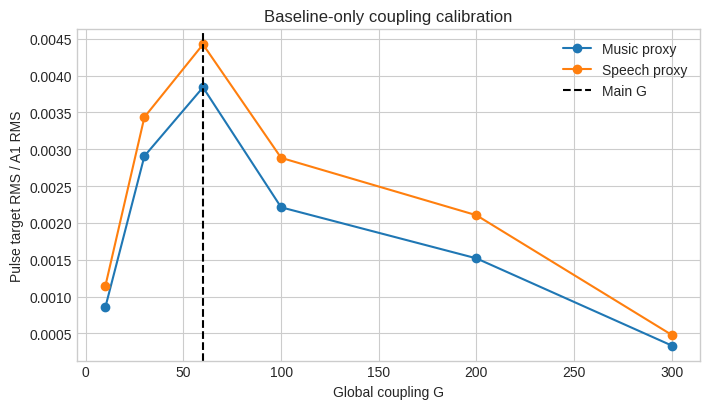

In [ ]:
calibration_rows = []
calibration_simulation_ms = 4000.0
calibration_seed = CFG["seeds"][0]

for candidate_g in progress_iter(
    CFG["calibration_couplings"], "baseline coupling scan"
):
    t_control, y_control, control_wall = run_tvb(
        BASELINE_B,
        None,
        candidate_g,
        MAIN_INPUT_PEAK_PER_MS,
        calibration_seed,
        simulation_ms=calibration_simulation_ms,
    )
    t_pulse, y_pulse, pulse_wall = run_tvb(
        BASELINE_B,
        "pulse",
        candidate_g,
        MAIN_INPUT_PEAK_PER_MS,
        calibration_seed,
        simulation_ms=calibration_simulation_ms,
    )
    if not np.allclose(t_control, t_pulse):
        raise RuntimeError("Calibration time axes differ.")
    response, _ = pulse_rms(t_pulse, y_pulse - y_control)
    a1 = float(np.mean(response[A1_INDICES]))
    music = float(np.mean(response[MUSIC_INDICES]))
    speech = float(np.mean(response[SPEECH_INDICES]))
    calibration_rows.append(
        {
            "global_coupling": candidate_g,
            "a1_rms": a1,
            "music_transfer": music / a1,
            "speech_transfer": speech / a1,
            "balanced_target_score": math.sqrt((music / a1) * (speech / a1)),
            "max_abs_evoked": float(np.max(np.abs(y_pulse - y_control))),
            "wall_seconds": control_wall + pulse_wall,
        }
    )

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df)
if not np.isfinite(calibration_df.select_dtypes("number")).all().all():
    raise RuntimeError("Calibration produced a nonfinite value.")
selected_row = calibration_df[
    calibration_df["global_coupling"] == MAIN_GLOBAL_COUPLING
]
if selected_row.empty:
    warnings.warn(
        "The selected coupling was not included in this shortened scan."
    )
elif float(selected_row["max_abs_evoked"].iloc[0]) >= 50.0:
    raise RuntimeError("The selected coupling produced a saturated response.")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(
    calibration_df["global_coupling"],
    calibration_df["music_transfer"],
    marker="o",
    label="Music proxy",
)
ax.plot(
    calibration_df["global_coupling"],
    calibration_df["speech_transfer"],
    marker="o",
    label="Speech proxy",
)
ax.axvline(MAIN_GLOBAL_COUPLING, color="black", linestyle="--", label="Main G")
ax.set(
    xlabel="Global coupling G",
    ylabel="Pulse target RMS / A1 RMS",
    title="Baseline-only coupling calibration",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_baseline_coupling_calibration.png", dpi=180)
plt.show()

## 11. Run the main full-field experiment

Each stimulated run is paired with an unstimulated run that has the same inhibitory vector and initial condition. Both proxy networks are measured from every simulation, so the stimulus is never changed between the network comparisons.

In [ ]:
main_conditions = [
    {
        "condition": SEVERITY_LABELS[severity],
        "severity": severity,
        "b_values": B_BY_SEVERITY[severity],
        "variant": "full_field",
    }
    for severity in CFG["severities"]
]

main_node_df, main_network_df, main_manifest_df = execute_grid(
    scope="main_full_field",
    conditions=main_conditions,
    seeds=CFG["seeds"],
    probes=PROBES,
    global_coupling=MAIN_GLOBAL_COUPLING,
    input_peak_per_ms=MAIN_INPUT_PEAK_PER_MS,
)
main_normalized_df = normalize_to_baseline(main_network_df)
main_contrast_df = make_contrasts(main_normalized_df)

display(main_network_df.head())
display(
    main_contrast_df[
        main_contrast_df["probe"].isin(PERIODIC_PROBES)
    ].sort_values(["probe", "seed", "severity"])
)

main_full_field: 0/45
2026-07-28 01:05:55,265 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:07:09,766 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:08:24,222 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:09:38,022 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:10:51,949 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:12:06,031 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
main_full_field: 4/45
2026-07-28 01:13:19,867 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:14:33,264 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 01:15:47,

,scope,variant,condition,severity,seed,probe,metric,global_coupling,input_peak_per_ms,dt_ms,b_signature,network,network_response,a1_response,transfer,median_target_fit_r_squared
0,main_full_field,full_field,Baseline,0.0,11,pulse,pulse_rms,60.0,0.02,1.0,512a8299eaef29ce,music,0.000260,0.067598,0.003840,NaN
1,main_full_field,full_field,Baseline,0.0,11,pulse,pulse_rms,60.0,0.02,1.0,512a8299eaef29ce,speech,0.000299,0.067598,0.004424,NaN
2,main_full_field,full_field,Baseline,0.0,11,2Hz,harmonic_amplitude,60.0,0.02,1.0,512a8299eaef29ce,music,0.000029,0.061539,0.000472,0.835328
3,main_full_field,full_field,Baseline,0.0,11,2Hz,harmonic_amplitude,60.0,0.02,1.0,512a8299eaef29ce,speech,0.000040,0.061539,0.000646,0.920789
4,main_full_field,full_field,Baseline,0.0,11,5Hz,harmonic_amplitude,60.0,0.02,1.0,512a8299eaef29ce,music,0.000054,0.082060,0.000656,0.932263


network,scope,variant,condition,severity,seed,probe,global_coupling,input_peak_per_ms,dt_ms,music,speech,music_minus_speech_log2_change
0,main_full_field,full_field,Baseline,0.0,11,2Hz,60.0,0.02,1.0,0.000000,0.000000,0.000000
30,main_full_field,full_field,Intermediate AD-like perturbation,0.5,11,2Hz,60.0,0.02,1.0,1.379047,-0.191436,1.570483
15,main_full_field,full_field,High AD-like perturbation,1.0,11,2Hz,60.0,0.02,1.0,2.031812,0.274013,1.757799
3,main_full_field,full_field,Baseline,0.0,23,2Hz,60.0,0.02,1.0,0.000000,0.000000,0.000000
33,main_full_field,full_field,Intermediate AD-like perturbation,0.5,23,2Hz,60.0,0.02,1.0,2.014407,0.165620,1.848788
18,main_full_field,full_field,High AD-like perturbation,1.0,23,2Hz,60.0,0.02,1.0,2.089685,0.053452,2.036233
6,main_full_field,full_field,Baseline,0.0,37,2Hz,60.0,0.02,1.0,0.000000,0.000000,0.000000
36,main_full_field,full_field,Intermediate AD-like perturbation,0.5,37,2Hz,60.0,0.02,1.0,1.792231,-0.232972,2.025202
21,main_full_field,full_field,High AD-like perturbation,1.0,37,2Hz,60.0,0.02,1.0,2.126766,0.308872,1.817893
9,main_full_field,full_field,Baseline,0.0,53,2Hz,60.0,0.02,1.0,0.000000,0.000000,0.000000


In [ ]:
main_stage_summary_df = (
    main_normalized_df.groupby(
        ["probe", "severity", "condition", "network"], as_index=False
    )
    .agg(
        median_log2_change=("log2_transfer_vs_baseline", "median"),
        minimum_log2_change=("log2_transfer_vs_baseline", "min"),
        maximum_log2_change=("log2_transfer_vs_baseline", "max"),
        numerical_seeds=("seed", "nunique"),
    )
    .sort_values(["probe", "severity", "network"])
)
primary_endpoint_df = main_contrast_df[
    (main_contrast_df["severity"] == 1.0)
    & (main_contrast_df["probe"].isin(PERIODIC_PROBES))
].copy()

display(main_stage_summary_df)
display(primary_endpoint_df)
print(
    "These ranges summarize numerical initial-condition sensitivity. "
    "They are not participant confidence intervals."
)

,probe,severity,condition,network,median_log2_change,minimum_log2_change,maximum_log2_change,numerical_seeds
0,2Hz,0.0,Baseline,music,0.000000,0.000000,0.000000,5
1,2Hz,0.0,Baseline,speech,0.000000,0.000000,0.000000,5
2,2Hz,0.5,Intermediate AD-like perturbation,music,1.792231,1.379047,2.799609,5
3,2Hz,0.5,Intermediate AD-like perturbation,speech,0.165620,-0.232972,0.635212,5
4,2Hz,1.0,High AD-like perturbation,music,2.118727,2.031812,2.130562,5
5,2Hz,1.0,High AD-like perturbation,speech,0.274013,0.053452,0.669444,5
6,5Hz,0.0,Baseline,music,0.000000,0.000000,0.000000,5
7,5Hz,0.0,Baseline,speech,0.000000,0.000000,0.000000,5
8,5Hz,0.5,Intermediate AD-like perturbation,music,4.505801,4.448103,4.613021,5
9,5Hz,0.5,Intermediate AD-like perturbation,speech,-0.021245,-0.139249,0.970867,5


network,scope,variant,condition,severity,seed,probe,global_coupling,input_peak_per_ms,dt_ms,music,speech,music_minus_speech_log2_change
15,main_full_field,full_field,High AD-like perturbation,1.0,11,2Hz,60.0,0.02,1.0,2.031812,0.274013,1.757799
16,main_full_field,full_field,High AD-like perturbation,1.0,11,5Hz,60.0,0.02,1.0,1.918485,-0.225927,2.144412
18,main_full_field,full_field,High AD-like perturbation,1.0,23,2Hz,60.0,0.02,1.0,2.089685,0.053452,2.036233
19,main_full_field,full_field,High AD-like perturbation,1.0,23,5Hz,60.0,0.02,1.0,1.941575,-0.582696,2.524271
21,main_full_field,full_field,High AD-like perturbation,1.0,37,2Hz,60.0,0.02,1.0,2.126766,0.308872,1.817893
22,main_full_field,full_field,High AD-like perturbation,1.0,37,5Hz,60.0,0.02,1.0,2.057069,-0.119323,2.176392
24,main_full_field,full_field,High AD-like perturbation,1.0,53,2Hz,60.0,0.02,1.0,2.118727,0.669444,1.449283
25,main_full_field,full_field,High AD-like perturbation,1.0,53,5Hz,60.0,0.02,1.0,1.864229,0.296431,1.567798
27,main_full_field,full_field,High AD-like perturbation,1.0,71,2Hz,60.0,0.02,1.0,2.130562,0.210790,1.919772
28,main_full_field,full_field,High AD-like perturbation,1.0,71,5Hz,60.0,0.02,1.0,2.024861,-0.310283,2.335144


These ranges summarize numerical initial-condition sensitivity. They are not participant confidence intervals.


## 12. Required local-dynamics-held-baseline counterfactual

The full surrogate endpoint gives the declared A1, music, and speech parcels different local inhibitory changes. That can create an apparent network difference even without a transmission difference.

This counterfactual repeats the high endpoint while holding \(b=0.07\) in A1 and every declared target parcel. All other parcels retain the high AD-like perturbation. Persistence of the contrast here is stronger evidence for a network-mediated effect, although it still does not isolate one anatomical route.

In [ ]:
LOCAL_FIXED_HIGH_B = HIGH_B.copy()
LOCAL_FIXED_HIGH_B[ALL_DECLARED_INDICES] = BASELINE_B[ALL_DECLARED_INDICES]

local_fixed_conditions = [
    {
        "condition": "High AD-like perturbation, declared local dynamics fixed",
        "severity": 1.0,
        "b_values": LOCAL_FIXED_HIGH_B,
        "variant": "local_fixed_endpoint",
    }
]
(
    local_fixed_node_df,
    local_fixed_network_df,
    local_fixed_manifest_df,
) = execute_grid(
    scope="local_dynamics_counterfactual",
    conditions=local_fixed_conditions,
    seeds=CFG["seeds"],
    probes=PROBES,
    global_coupling=MAIN_GLOBAL_COUPLING,
    input_peak_per_ms=MAIN_INPUT_PEAK_PER_MS,
)
local_fixed_normalized_df = normalize_to_baseline(
    local_fixed_network_df,
    baseline_df=main_network_df,
)
local_fixed_contrast_df = make_contrasts(local_fixed_normalized_df)

counterfactual_comparison_df = pd.concat(
    [
        primary_endpoint_df.assign(analysis="Full regional perturbation"),
        local_fixed_contrast_df[
            local_fixed_contrast_df["probe"].isin(PERIODIC_PROBES)
        ].assign(analysis="A1 and target local dynamics fixed"),
    ],
    ignore_index=True,
)
display(
    counterfactual_comparison_df[
        [
            "analysis",
            "seed",
            "probe",
            "music",
            "speech",
            "music_minus_speech_log2_change",
        ]
    ].sort_values(["probe", "seed", "analysis"])
)

local_dynamics_counterfactual: 0/15
2026-07-28 02:20:03,079 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 02:21:14,899 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
local_dynamics_counterfactual: 1/15
2026-07-28 02:22:27,539 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
local_dynamics_counterfactual: 2/15
2026-07-28 02:23:40,517 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
local_dynamics_counterfactual: 3/15
2026-07-28 02:24:52,918 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 02:26:05,430 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
local_dynamics_counterfactual: 4/15
2026-07-28 02:27:18,371 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
l

network,analysis,seed,probe,music,speech,music_minus_speech_log2_change
10,A1 and target local dynamics fixed,11,2Hz,0.249039,0.199346,0.049693
0,Full regional perturbation,11,2Hz,2.031812,0.274013,1.757799
12,A1 and target local dynamics fixed,23,2Hz,0.063151,0.071506,-0.008355
2,Full regional perturbation,23,2Hz,2.089685,0.053452,2.036233
14,A1 and target local dynamics fixed,37,2Hz,0.127047,0.116099,0.010948
4,Full regional perturbation,37,2Hz,2.126766,0.308872,1.817893
16,A1 and target local dynamics fixed,53,2Hz,0.098734,0.093038,0.005696
6,Full regional perturbation,53,2Hz,2.118727,0.669444,1.449283
18,A1 and target local dynamics fixed,71,2Hz,0.202276,0.148392,0.053883
8,Full regional perturbation,71,2Hz,2.130562,0.210790,1.919772


## 13. Topology and pathology-matched control subnetworks

Raw network differences can reflect parcel strength, direct A1 connectivity, or local inhibitory perturbation. This section generates equal-sized bilateral cortical control groups matched to each declared target group on:

- symmetrized weighted strength;
- symmetrized direct structural affinity to bilateral A1;
- high-endpoint local reduction in \(b\).

Symmetrization is used only to calculate matching features. The TVB simulation continues to use the original directed/asymmetric matrix. The resulting null percentiles describe this simulation and are not clinical p-values.

In [ ]:
MATCH_WEIGHTS = 0.5 * (WEIGHTS + WEIGHTS.T)
CORTICAL_INDICES = np.arange(360)
weighted_strength = MATCH_WEIGHTS.sum(axis=1)
direct_a1_affinity = MATCH_WEIGHTS[:, A1_INDICES].sum(axis=1)
local_b_reduction = BASELINE_B - HIGH_B

raw_features = np.column_stack(
    [
        np.log10(weighted_strength + 1e-15),
        np.log10(direct_a1_affinity + 1e-15),
        local_b_reduction,
    ]
)
cortical_mean = raw_features[CORTICAL_INDICES].mean(axis=0)
cortical_std = raw_features[CORTICAL_INDICES].std(axis=0)
if np.any(cortical_std <= 0):
    raise RuntimeError("A matching feature has zero variance.")
matching_z = (raw_features - cortical_mean) / cortical_std

target_feature_df = pd.DataFrame(
    {
        "label": [*MUSIC_LABELS, *SPEECH_LABELS],
        "network": ["music"] * len(MUSIC_LABELS)
        + ["speech"] * len(SPEECH_LABELS),
        "weighted_strength": weighted_strength[
            np.r_[MUSIC_INDICES, SPEECH_INDICES]
        ],
        "direct_A1_affinity": direct_a1_affinity[
            np.r_[MUSIC_INDICES, SPEECH_INDICES]
        ],
        "local_b_reduction": local_b_reduction[
            np.r_[MUSIC_INDICES, SPEECH_INDICES]
        ],
    }
)
display(target_feature_df)

def same_hemisphere_candidates(target_index):
    if target_index < 180:
        return np.arange(0, 180)
    if target_index < 360:
        return np.arange(180, 360)
    raise ValueError("Matched targets must be cortical.")

def draw_matched_set(target_indices, rng, reserved, top_k=30):
    selected = []
    distances_selected = []
    for target_index in target_indices:
        candidates = same_hemisphere_candidates(int(target_index))
        candidates = np.array(
            [
                index
                for index in candidates
                if index not in reserved and index not in selected
            ],
            dtype=int,
        )
        distances = np.linalg.norm(
            matching_z[candidates] - matching_z[target_index], axis=1
        )
        order = np.argsort(distances)
        pool_order = order[: min(top_k, len(order))]
        pool = candidates[pool_order]
        pool_distances = distances[pool_order]
        scale = max(float(np.median(pool_distances)), 1e-6)
        probabilities = np.exp(-(pool_distances - pool_distances.min()) / scale)
        probabilities /= probabilities.sum()
        chosen = int(rng.choice(pool, p=probabilities))
        selected.append(chosen)
        distances_selected.append(
            float(np.linalg.norm(matching_z[chosen] - matching_z[target_index]))
        )
    return np.array(selected, dtype=int), distances_selected

matched_rng = np.random.default_rng(20260727)
excluded = set(ALL_DECLARED_INDICES.tolist())
matched_set_rows = []
for set_id in range(CFG["matched_null_sets"]):
    music_control, music_distances = draw_matched_set(
        MUSIC_INDICES, matched_rng, reserved=excluded
    )
    speech_control, speech_distances = draw_matched_set(
        SPEECH_INDICES,
        matched_rng,
        reserved=excluded.union(music_control.tolist()),
    )
    matched_set_rows.append(
        {
            "set_id": set_id,
            "music_control_indices": ";".join(map(str, music_control)),
            "speech_control_indices": ";".join(map(str, speech_control)),
            "music_control_labels": ";".join(LABELS[music_control]),
            "speech_control_labels": ";".join(LABELS[speech_control]),
            "mean_standardized_match_distance": float(
                np.mean(music_distances + speech_distances)
            ),
        }
    )
matched_sets_df = pd.DataFrame(matched_set_rows)
display(matched_sets_df.head())
display(matched_sets_df["mean_standardized_match_distance"].describe())

,label,network,weighted_strength,direct_A1_affinity,local_b_reduction
0,L_6ma,music,0.552659,0.001961,0.014397
1,R_6ma,music,0.590208,0.001910,0.029591
2,L_24dd,music,0.469139,0.001195,0.010169
3,R_24dd,music,0.468012,0.001987,0.049539
4,L_STSdp,speech,0.454398,0.002452,0.008871
5,R_STSdp,speech,0.532800,0.002799,0.004696
6,L_44,speech,0.505659,0.002037,0.001741
7,R_44,speech,0.520810,0.001980,0.020922


,set_id,music_control_indices,speech_control_indices,music_control_labels,speech_control_labels,mean_standardized_match_distance
0,0,30;293;129;329,12;232;37;257,L_POS1;R_FOP3;L_STSvp;R_PGi,L_V3A;R_3a;L_23c;R_6r,0.809432
1,1,149;180;59;283,83;226;142;356,L_PGi;R_V1;L_p32pr;R_RI,L_46;R_7PC;L_PGp;R_TE1m,0.827762
2,2,142;316;70;313,9;354;68;246,L_PGp;R_PHT;L_9p;R_TE2a,L_FEF;R_A4;L_9m;R_8Av,0.839241
3,3,129;216;40;318,28;229;136;235,L_STSvp;R_5mv;L_24dv;R_TPOJ1,L_7Pm;R_MIP;L_PHT;R_6v,0.939275
4,4,129;227;12;336,48;205;83;184,L_STSvp;R_LIPv;L_V3A;R_FST,L_VIP;R_SFL;L_46;R_V3,0.960087


,mean_standardized_match_distance
count,500.000000
mean,0.775659
std,0.101233
min,0.489923
25%,0.711748
50%,0.778256
75%,0.846158
max,1.058600


In [ ]:
def node_response_vector(node_df, seed, probe, severity):
    subset = node_df[
        (node_df["seed"] == seed)
        & (node_df["probe"] == probe)
        & (node_df["severity"] == severity)
    ].sort_values("region_index")
    if len(subset) != N_REGIONS:
        raise RuntimeError("Expected exactly one response per region.")
    return subset["response"].to_numpy()

def a1_response_value(network_df, seed, probe, severity):
    subset = network_df[
        (network_df["seed"] == seed)
        & (network_df["probe"] == probe)
        & (network_df["severity"] == severity)
    ]
    values = subset["a1_response"].unique()
    if len(values) != 1:
        raise RuntimeError("Expected one A1 response value.")
    return float(values[0])

matched_null_rows = []
for seed in CFG["seeds"]:
    for probe in PERIODIC_PROBES:
        baseline_response = node_response_vector(
            main_node_df, seed, probe, 0.0
        )
        high_response = node_response_vector(main_node_df, seed, probe, 1.0)
        baseline_a1 = a1_response_value(
            main_network_df, seed, probe, 0.0
        )
        high_a1 = a1_response_value(main_network_df, seed, probe, 1.0)

        for row in matched_sets_df.itertuples(index=False):
            music_control = np.fromstring(
                row.music_control_indices, sep=";", dtype=int
            )
            speech_control = np.fromstring(
                row.speech_control_indices, sep=";", dtype=int
            )
            music_baseline_transfer = (
                np.mean(baseline_response[music_control]) / baseline_a1
            )
            music_high_transfer = (
                np.mean(high_response[music_control]) / high_a1
            )
            speech_baseline_transfer = (
                np.mean(baseline_response[speech_control]) / baseline_a1
            )
            speech_high_transfer = (
                np.mean(high_response[speech_control]) / high_a1
            )
            music_change = np.log2(
                max(music_high_transfer, 1e-15)
                / max(music_baseline_transfer, 1e-15)
            )
            speech_change = np.log2(
                max(speech_high_transfer, 1e-15)
                / max(speech_baseline_transfer, 1e-15)
            )
            matched_null_rows.append(
                {
                    "set_id": row.set_id,
                    "seed": seed,
                    "probe": probe,
                    "music_control_log2_change": music_change,
                    "speech_control_log2_change": speech_change,
                    "null_music_minus_speech": music_change - speech_change,
                    "mean_standardized_match_distance": (
                        row.mean_standardized_match_distance
                    ),
                }
            )

matched_null_df = pd.DataFrame(matched_null_rows)
matched_null_summary_rows = []
for observed in primary_endpoint_df.itertuples(index=False):
    null_values = matched_null_df[
        (matched_null_df["seed"] == observed.seed)
        & (matched_null_df["probe"] == observed.probe)
    ]["null_music_minus_speech"].to_numpy()
    observed_value = observed.music_minus_speech_log2_change
    matched_null_summary_rows.append(
        {
            "seed": observed.seed,
            "probe": observed.probe,
            "observed_contrast": observed_value,
            "null_median": float(np.median(null_values)),
            "null_5th_percentile": float(np.quantile(null_values, 0.05)),
            "null_95th_percentile": float(np.quantile(null_values, 0.95)),
            "observed_percentile_within_simulation_null": float(
                100.0 * np.mean(null_values <= observed_value)
            ),
        }
    )
matched_null_summary_df = pd.DataFrame(matched_null_summary_rows)
display(matched_null_summary_df)

,seed,probe,observed_contrast,null_median,null_5th_percentile,null_95th_percentile,observed_percentile_within_simulation_null
0,11,2Hz,1.757799,1.652378,-0.596160,3.934682,54.4
1,11,5Hz,2.144412,1.811467,-1.489231,5.258192,57.0
2,23,2Hz,2.036233,1.687968,-0.520327,4.016291,63.2
3,23,5Hz,2.524271,1.839355,-1.646394,6.839449,64.4
4,37,2Hz,1.817893,1.497023,-0.447710,3.697135,62.4
5,37,5Hz,2.176392,1.668120,-1.432474,5.738217,60.6
6,53,2Hz,1.449283,1.621353,-0.537343,3.880299,45.4
7,53,5Hz,1.567798,1.737518,-1.710728,6.869061,47.8
8,71,2Hz,1.919772,1.621130,-0.528942,4.018512,59.4
9,71,5Hz,2.335144,1.828563,-1.677580,6.302712,59.6


## 14. Coupling and stimulus-strength sensitivity

The main endpoint is repeated at lower and higher global coupling and input strength. These checks use one numerical seed to control runtime. A conclusion is more credible when its direction is not unique to \(G=60\) and input peak \(0.02\).

In [ ]:
sensitivity_network_frames = []
sensitivity_manifest_frames = []

main_seed = CFG["seeds"][0]
main_sensitivity_source = main_network_df[
    (main_network_df["seed"] == main_seed)
    & (main_network_df["severity"].isin([0.0, 1.0]))
    & (main_network_df["probe"].isin(PERIODIC_PROBES))
].copy()
main_sensitivity_source["scope"] = "sensitivity_main"
main_sensitivity_source["variant"] = "G60_input_0.02"
sensitivity_network_frames.append(main_sensitivity_source)

for scenario in CFG["sensitivity_scenarios"]:
    scenario_name = scenario["scenario"]
    _, scenario_network_df, scenario_manifest_df = execute_grid(
        scope=f"sensitivity_{scenario_name}",
        conditions=[
            {
                "condition": SEVERITY_LABELS[severity],
                "severity": severity,
                "b_values": B_BY_SEVERITY[severity],
                "variant": scenario_name,
            }
            for severity in (0.0, 1.0)
        ],
        seeds=[main_seed],
        probes=PERIODIC_PROBES,
        global_coupling=scenario["global_coupling"],
        input_peak_per_ms=scenario["input_peak"],
    )
    sensitivity_network_frames.append(scenario_network_df)
    sensitivity_manifest_frames.append(scenario_manifest_df)

sensitivity_network_df = pd.concat(
    sensitivity_network_frames, ignore_index=True
)
sensitivity_normalized_frames = []
for scope, group in sensitivity_network_df.groupby("scope", sort=False):
    sensitivity_normalized_frames.append(normalize_to_baseline(group))
sensitivity_normalized_df = pd.concat(
    sensitivity_normalized_frames, ignore_index=True
)
sensitivity_contrast_df = make_contrasts(sensitivity_normalized_df)
sensitivity_endpoint_df = sensitivity_contrast_df[
    sensitivity_contrast_df["severity"] == 1.0
].copy()
display(
    sensitivity_endpoint_df[
        [
            "variant",
            "probe",
            "global_coupling",
            "input_peak_per_ms",
            "music_minus_speech_log2_change",
        ]
    ].sort_values(["probe", "global_coupling", "input_peak_per_ms"])
)

sensitivity_G30: 0/4
2026-07-28 02:44:26,750 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 02:45:38,903 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
sensitivity_G30: 1/4
2026-07-28 02:46:53,133 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
sensitivity_G30: 2/4
2026-07-28 02:48:07,290 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 02:49:19,490 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
sensitivity_G30: 3/4
2026-07-28 02:50:33,412 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
sensitivity_G30: 4/4
sensitivity_G100: 0/4
2026-07-28 02:51:46,924 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 02:52:58,725 - WARNING - tvb.simulator.inte

network,variant,probe,global_coupling,input_peak_per_ms,music_minus_speech_log2_change
6,G30,2Hz,30.0,0.02,3.008533
10,input_0.01,2Hz,60.0,0.01,1.755562
18,G60_input_0.02,2Hz,60.0,0.02,1.757799
14,input_0.04,2Hz,60.0,0.04,1.762368
2,G100,2Hz,100.0,0.02,1.889082
7,G30,5Hz,30.0,0.02,0.109935
11,input_0.01,5Hz,60.0,0.01,2.143595
19,G60_input_0.02,5Hz,60.0,0.02,2.144412
15,input_0.04,5Hz,60.0,0.04,2.147102
3,G100,5Hz,100.0,0.02,3.923636


## 15. Spatial-placement sensitivity

The high-endpoint \(b\) values are shuffled separately within left cortex, right cortex, and the 19 subcortical/brainstem parcels. This preserves the overall perturbation distribution and broad anatomical blocks while changing its regional placement.

Five final-mode shuffles are a descriptive robustness check, not a definitive spatial randomization test.

In [ ]:
shuffle_rng = np.random.default_rng(3792026)
shuffle_network_frames = []
shuffle_manifest_frames = []
shuffle_blocks = [np.arange(0, 180), np.arange(180, 360), np.arange(360, 379)]

for shuffle_id in range(CFG["spatial_shuffles"]):
    shuffled_b = HIGH_B.copy()
    for block in shuffle_blocks:
        shuffled_b[block] = shuffle_rng.permutation(HIGH_B[block])
    _, shuffle_network_df, shuffle_manifest_df = execute_grid(
        scope=f"spatial_shuffle_{shuffle_id + 1:02d}",
        conditions=[
            {
                "condition": "High AD-like perturbation, spatially shuffled",
                "severity": 1.0,
                "b_values": shuffled_b,
                "variant": f"shuffle_{shuffle_id + 1:02d}",
            }
        ],
        seeds=[main_seed],
        probes=PERIODIC_PROBES,
        global_coupling=MAIN_GLOBAL_COUPLING,
        input_peak_per_ms=MAIN_INPUT_PEAK_PER_MS,
    )
    shuffle_network_frames.append(shuffle_network_df)
    shuffle_manifest_frames.append(shuffle_manifest_df)

shuffle_network_df = pd.concat(shuffle_network_frames, ignore_index=True)
shuffle_normalized_frames = []
for scope, group in shuffle_network_df.groupby("scope", sort=False):
    shuffle_normalized_frames.append(
        normalize_to_baseline(group, baseline_df=main_network_df)
    )
shuffle_normalized_df = pd.concat(
    shuffle_normalized_frames, ignore_index=True
)
shuffle_contrast_df = make_contrasts(shuffle_normalized_df)

observed_first_seed_df = primary_endpoint_df[
    primary_endpoint_df["seed"] == main_seed
][["probe", "music_minus_speech_log2_change"]].rename(
    columns={"music_minus_speech_log2_change": "observed_contrast"}
)
shuffle_summary_df = (
    shuffle_contrast_df.groupby("probe", as_index=False)
    .agg(
        shuffle_median=("music_minus_speech_log2_change", "median"),
        shuffle_minimum=("music_minus_speech_log2_change", "min"),
        shuffle_maximum=("music_minus_speech_log2_change", "max"),
        spatial_shuffles=("variant", "nunique"),
    )
    .merge(observed_first_seed_df, on="probe", how="left")
)
display(shuffle_summary_df)

spatial_shuffle_01: 0/2
2026-07-28 03:13:56,824 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 03:15:10,378 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
spatial_shuffle_01: 1/2
2026-07-28 03:16:22,553 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
spatial_shuffle_01: 2/2
spatial_shuffle_02: 0/2
2026-07-28 03:17:36,197 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 03:18:50,266 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
spatial_shuffle_02: 1/2
2026-07-28 03:20:05,039 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
spatial_shuffle_02: 2/2
spatial_shuffle_03: 0/2
2026-07-28 03:21:18,965 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 03

,probe,shuffle_median,shuffle_minimum,shuffle_maximum,spatial_shuffles,observed_contrast
0,2Hz,0.367995,-1.707838,1.501208,5,1.757799
1,5Hz,0.434689,-0.645793,1.923052,5,2.144412


## 16. Required integration-step convergence check

The baseline 2 Hz result at the 1.0 ms main step is compared with a 0.5 ms reference run. The notebook stops if either target transfer differs by 5% or more.

In [ ]:
_, dt_reference_network_df, dt_reference_manifest_df = execute_grid(
    scope="dt_reference_0.5ms",
    conditions=[
        {
            "condition": SEVERITY_LABELS[0.0],
            "severity": 0.0,
            "b_values": BASELINE_B,
            "variant": "dt_0.5ms",
        }
    ],
    seeds=[main_seed],
    probes=["2Hz"],
    global_coupling=MAIN_GLOBAL_COUPLING,
    input_peak_per_ms=MAIN_INPUT_PEAK_PER_MS,
    dt_ms=REFERENCE_DT_MS,
)

dt_main = main_network_df[
    (main_network_df["seed"] == main_seed)
    & (main_network_df["severity"] == 0.0)
    & (main_network_df["probe"] == "2Hz")
][["network", "transfer"]].rename(columns={"transfer": "transfer_dt_1.0ms"})
dt_reference = dt_reference_network_df[
    ["network", "transfer"]
].rename(columns={"transfer": "transfer_dt_0.5ms"})
dt_convergence_df = dt_main.merge(
    dt_reference, on="network", validate="one_to_one"
)
dt_convergence_df["relative_difference"] = (
    (
        dt_convergence_df["transfer_dt_1.0ms"]
        - dt_convergence_df["transfer_dt_0.5ms"]
    ).abs()
    / dt_convergence_df["transfer_dt_0.5ms"].abs().clip(lower=1e-15)
)
display(dt_convergence_df)
if (dt_convergence_df["relative_difference"] >= 0.05).any():
    raise RuntimeError(
        "The 1.0 ms integration step failed the prespecified 5% convergence check."
    )
print("Integration-step convergence check passed.")

dt_reference_0.5ms: 0/1
2026-07-28 03:32:30,959 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
2026-07-28 03:34:58,706 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration
dt_reference_0.5ms: 1/1


,network,transfer_dt_1.0ms,transfer_dt_0.5ms,relative_difference
0,music,0.000472,0.000471,0.000488
1,speech,0.000646,0.000646,0.000353


Integration-step convergence check passed.


## 17. Figures

Every numerical seed is shown when more than one is available. Thick lines summarize seed medians. These graphics describe model robustness and do not show human-subject uncertainty.

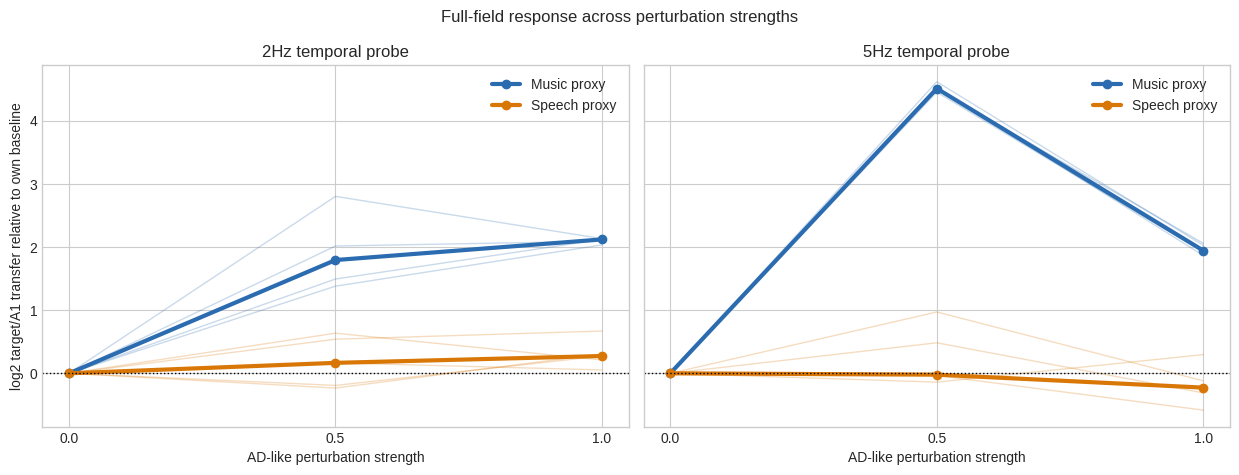

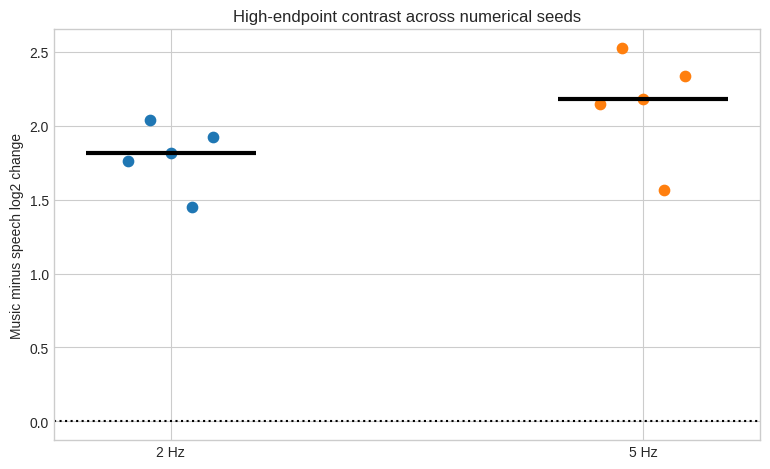

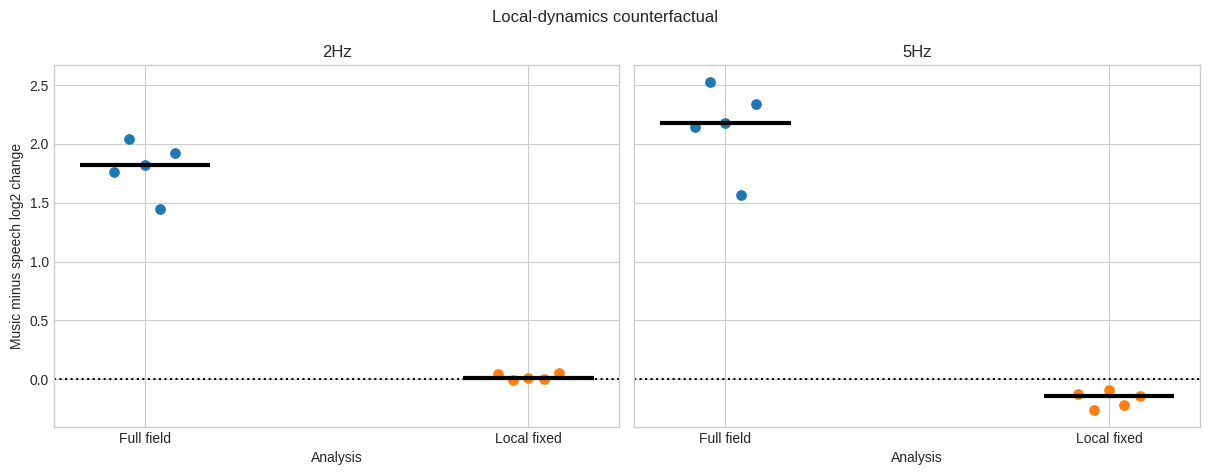

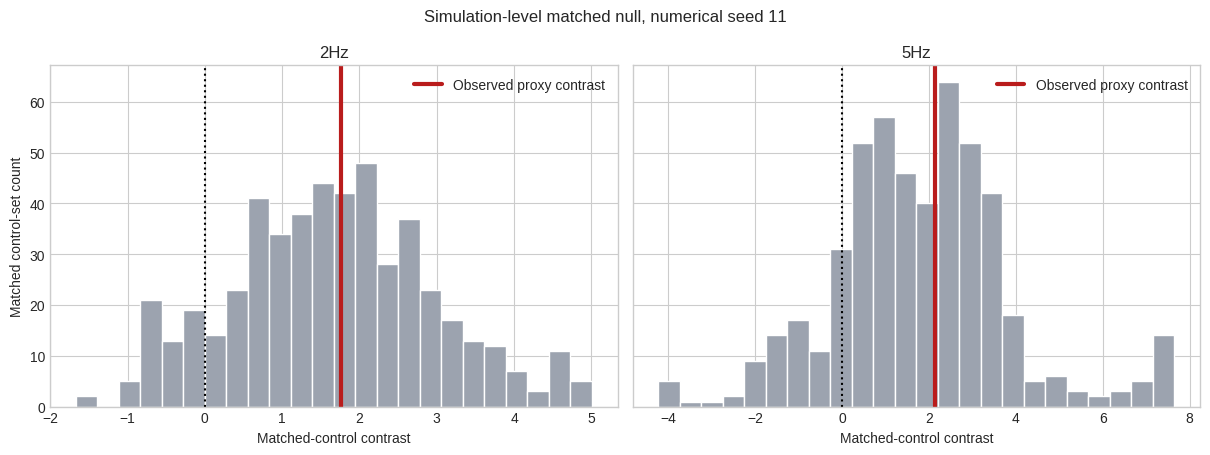

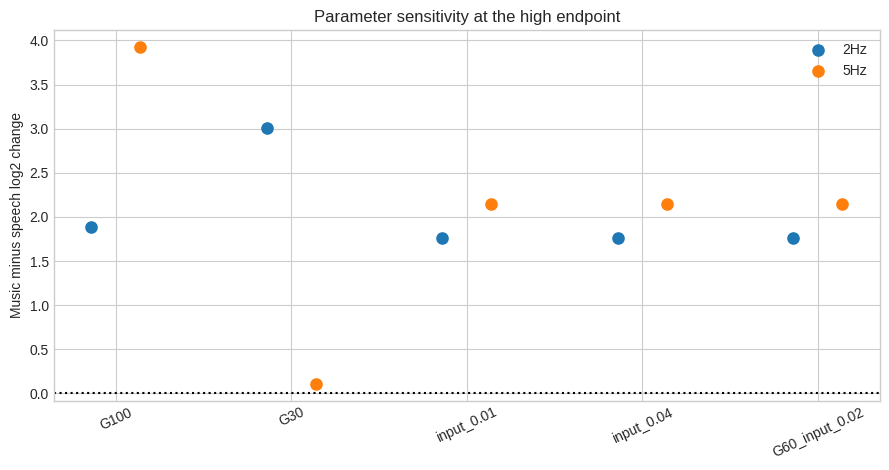

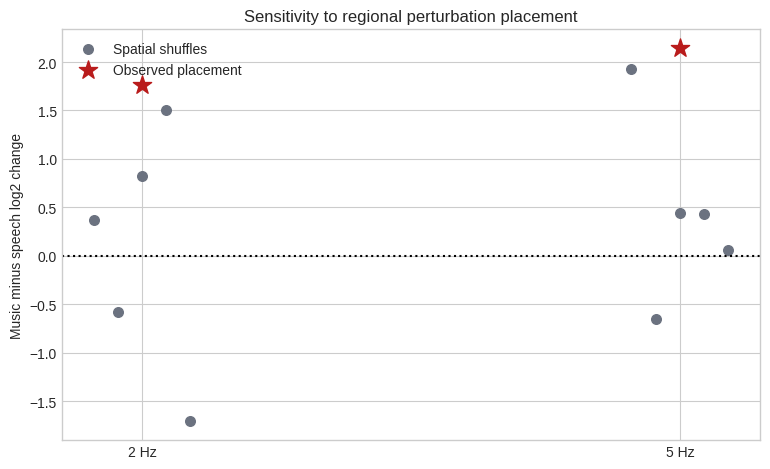

In [ ]:
NETWORK_COLORS = {"music": "#2B6CB0", "speech": "#D97706"}
NETWORK_NAMES = {"music": "Music proxy", "speech": "Speech proxy"}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, probe in zip(axes, PERIODIC_PROBES):
    plot_data = main_normalized_df[main_normalized_df["probe"] == probe]
    for network in ("music", "speech"):
        network_data = plot_data[plot_data["network"] == network]
        for _, seed_data in network_data.groupby("seed"):
            seed_data = seed_data.sort_values("severity")
            ax.plot(
                seed_data["severity"],
                seed_data["log2_transfer_vs_baseline"],
                color=NETWORK_COLORS[network],
                alpha=0.25,
                linewidth=1.0,
            )
        median_data = (
            network_data.groupby("severity", as_index=False)[
                "log2_transfer_vs_baseline"
            ].median()
        )
        ax.plot(
            median_data["severity"],
            median_data["log2_transfer_vs_baseline"],
            color=NETWORK_COLORS[network],
            marker="o",
            linewidth=3.0,
            label=NETWORK_NAMES[network],
        )
    ax.axhline(0.0, color="black", linewidth=1.0, linestyle=":")
    ax.set(
        title=f"{probe} temporal probe",
        xlabel="AD-like perturbation strength",
        xticks=sorted(main_normalized_df["severity"].unique()),
    )
    ax.legend()
axes[0].set_ylabel("log2 target/A1 transfer relative to own baseline")
fig.suptitle("Full-field response across perturbation strengths")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_main_stage_curves.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.8))
positions = {"2Hz": 0, "5Hz": 1}
for probe, probe_data in primary_endpoint_df.groupby("probe"):
    x0 = positions[probe]
    offsets = np.linspace(-0.09, 0.09, len(probe_data))
    ax.scatter(
        x0 + offsets,
        probe_data["music_minus_speech_log2_change"],
        s=55,
        label=probe,
    )
    ax.hlines(
        probe_data["music_minus_speech_log2_change"].median(),
        x0 - 0.18,
        x0 + 0.18,
        color="black",
        linewidth=3,
    )
ax.axhline(0.0, color="black", linestyle=":")
ax.set(
    xticks=[0, 1],
    xticklabels=["2 Hz", "5 Hz"],
    ylabel="Music minus speech log2 change",
    title="High-endpoint contrast across numerical seeds",
)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_primary_endpoint_contrast.png", dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharey=True)
analysis_order = [
    "Full regional perturbation",
    "A1 and target local dynamics fixed",
]
for ax, probe in zip(axes, PERIODIC_PROBES):
    subset = counterfactual_comparison_df[
        counterfactual_comparison_df["probe"] == probe
    ]
    for position, analysis in enumerate(analysis_order):
        values = subset[subset["analysis"] == analysis][
            "music_minus_speech_log2_change"
        ].to_numpy()
        offsets = np.linspace(-0.08, 0.08, len(values))
        ax.scatter(position + offsets, values, s=45)
        ax.hlines(
            np.median(values),
            position - 0.17,
            position + 0.17,
            color="black",
            linewidth=3,
        )
    ax.axhline(0.0, color="black", linestyle=":")
    ax.set(
        title=probe,
        xticks=[0, 1],
        xticklabels=["Full field", "Local fixed"],
        xlabel="Analysis",
    )
axes[0].set_ylabel("Music minus speech log2 change")
fig.suptitle("Local-dynamics counterfactual")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_local_dynamics_counterfactual.png", dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), sharey=True)
for ax, probe in zip(axes, PERIODIC_PROBES):
    null_subset = matched_null_df[
        (matched_null_df["seed"] == main_seed)
        & (matched_null_df["probe"] == probe)
    ]["null_music_minus_speech"]
    observed_value = primary_endpoint_df[
        (primary_endpoint_df["seed"] == main_seed)
        & (primary_endpoint_df["probe"] == probe)
    ]["music_minus_speech_log2_change"].iloc[0]
    ax.hist(null_subset, bins=24, color="#9CA3AF", edgecolor="white")
    ax.axvline(
        observed_value,
        color="#B91C1C",
        linewidth=3,
        label="Observed proxy contrast",
    )
    ax.axvline(0.0, color="black", linestyle=":")
    ax.set(title=probe, xlabel="Matched-control contrast")
    ax.legend()
axes[0].set_ylabel("Matched control-set count")
fig.suptitle(f"Simulation-level matched null, numerical seed {main_seed}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_matched_control_null.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9.0, 4.8))
scenario_labels = list(dict.fromkeys(sensitivity_endpoint_df["variant"]))
x_positions = np.arange(len(scenario_labels))
width = 0.28
for offset, probe in [(-width / 2, "2Hz"), (width / 2, "5Hz")]:
    values = [
        sensitivity_endpoint_df[
            (sensitivity_endpoint_df["variant"] == scenario)
            & (sensitivity_endpoint_df["probe"] == probe)
        ]["music_minus_speech_log2_change"].iloc[0]
        for scenario in scenario_labels
    ]
    ax.scatter(
        x_positions + offset,
        values,
        s=65,
        label=probe,
    )
ax.axhline(0.0, color="black", linestyle=":")
ax.set(
    xticks=x_positions,
    xticklabels=scenario_labels,
    ylabel="Music minus speech log2 change",
    title="Parameter sensitivity at the high endpoint",
)
ax.tick_params(axis="x", rotation=25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_parameter_sensitivity.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7.8, 4.8))
for probe_index, probe in enumerate(PERIODIC_PROBES):
    shuffle_values = shuffle_contrast_df[
        shuffle_contrast_df["probe"] == probe
    ]["music_minus_speech_log2_change"].to_numpy()
    offsets = np.linspace(-0.09, 0.09, len(shuffle_values))
    ax.scatter(
        probe_index + offsets,
        shuffle_values,
        color="#6B7280",
        s=48,
        label="Spatial shuffles" if probe_index == 0 else None,
    )
    observed_value = observed_first_seed_df[
        observed_first_seed_df["probe"] == probe
    ]["observed_contrast"].iloc[0]
    ax.scatter(
        [probe_index],
        [observed_value],
        marker="*",
        s=190,
        color="#B91C1C",
        label="Observed placement" if probe_index == 0 else None,
    )
ax.axhline(0.0, color="black", linestyle=":")
ax.set(
    xticks=[0, 1],
    xticklabels=["2 Hz", "5 Hz"],
    ylabel="Music minus speech log2 change",
    title="Sensitivity to regional perturbation placement",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_spatial_placement_sensitivity.png", dpi=180)
plt.show()

## 18. Save all results and provenance

CSV files preserve the node-level and network-level outputs. The JSON metadata records sources, parameters, parcel definitions, and interpretation limits. The final ZIP can be downloaded from Colab.

In [ ]:
sensitivity_manifest_df = (
    pd.concat(sensitivity_manifest_frames, ignore_index=True)
    if sensitivity_manifest_frames
    else pd.DataFrame()
)
shuffle_manifest_df = pd.concat(shuffle_manifest_frames, ignore_index=True)
all_manifest_df = pd.concat(
    [
        main_manifest_df,
        local_fixed_manifest_df,
        sensitivity_manifest_df,
        shuffle_manifest_df,
        dt_reference_manifest_df,
    ],
    ignore_index=True,
)

output_tables = {
    "source_manifest.csv": source_manifest_df,
    "data_quality_checks.csv": data_quality_df,
    "roi_definitions.csv": roi_definition_df,
    "roi_pathology_values.csv": roi_pathology_df,
    "pathology_summary.csv": pathology_summary_df,
    "baseline_coupling_calibration.csv": calibration_df,
    "main_node_metrics.csv": main_node_df,
    "main_network_metrics.csv": main_network_df,
    "main_network_metrics_normalized.csv": main_normalized_df,
    "main_music_minus_speech_contrasts.csv": main_contrast_df,
    "main_stage_summary.csv": main_stage_summary_df,
    "local_fixed_node_metrics.csv": local_fixed_node_df,
    "local_fixed_network_metrics.csv": local_fixed_network_df,
    "local_fixed_contrasts.csv": local_fixed_contrast_df,
    "matched_control_sets.csv": matched_sets_df,
    "matched_control_null_metrics.csv": matched_null_df,
    "matched_control_null_summary.csv": matched_null_summary_df,
    "sensitivity_network_metrics.csv": sensitivity_network_df,
    "sensitivity_contrasts.csv": sensitivity_contrast_df,
    "spatial_shuffle_network_metrics.csv": shuffle_network_df,
    "spatial_shuffle_contrasts.csv": shuffle_contrast_df,
    "integration_step_check.csv": dt_convergence_df,
    "run_manifest.csv": all_manifest_df,
}
for filename, frame in output_tables.items():
    frame.to_csv(RESULTS_DIR / filename, index=False)

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "run_mode": RUN_MODE,
    "research_question": (
        "How does increasing AD-like amyloid-linked inhibitory dysfunction "
        "affect stimulus-evoked transmission from bilateral primary auditory "
        "cortex to music-associated versus speech-associated cortical proxy subnetworks?"
    ),
    "source_commits": {
        "educase": EDUCASE_COMMIT,
        "adni_tvb_pipeline": PIPELINE_COMMIT,
    },
    "source_hashes": {
        row.source: row.sha256
        for row in source_manifest_df.itertuples(index=False)
    },
    "model": {
        "regions": N_REGIONS,
        "global_coupling": MAIN_GLOBAL_COUPLING,
        "input_peak_per_ms": MAIN_INPUT_PEAK_PER_MS,
        "dt_ms": MAIN_DT_MS,
        "monitor_period_ms": MONITOR_PERIOD_MS,
        "simulation_ms": SIMULATION_MS,
        "stimulus_onset_ms": STIMULUS_ONSET_MS,
        "delays": "all zero, following the public educational model",
        "probes": list(PROBES),
        "numerical_seeds": CFG["seeds"],
    },
    "parcels": {
        "A1": list(A1_LABELS),
        "music_proxy": list(MUSIC_LABELS),
        "speech_proxy": list(SPEECH_LABELS),
    },
    "primary_metric": (
        "network harmonic amplitude divided by bilateral A1 harmonic amplitude, "
        "then log2-normalized to the same network's baseline"
    ),
    "primary_contrast": (
        "music log2 change minus speech log2 change"
    ),
    "interpretation_limits": [
        "The public amyloid endpoint is an artificial surrogate, not patient data.",
        "The model includes amyloid-linked inhibition but not tau, atrophy, synapse loss, inflammation, vascular disease, or structural degeneration.",
        "The connectome is one averaged healthy structural matrix for every condition.",
        "All interregional delays are zero.",
        "The 2 Hz and 5 Hz inputs are temporal probes, not literal music and speech.",
        "The parcel groups are approximate proxy subnetworks.",
        "The model contains no memory encoding or retrieval mechanism.",
        "Numerical seeds and matched control sets are not human subjects.",
    ],
}
(RESULTS_DIR / "experiment_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

archive_base = WORK_DIR / f"RISE_TVB379_results_{RUN_MODE}"
archive_path = shutil.make_archive(
    str(archive_base), "zip", root_dir=RESULTS_DIR
)
print("Saved result archive:", archive_path)
print("Total TVB simulations recorded:", len(all_manifest_df))
print(
    "Total recorded TVB wall time, minutes:",
    round(all_manifest_df["wall_seconds"].sum() / 60.0, 2),
)

if DOWNLOAD_RESULTS_AT_END and IS_COLAB:
    from google.colab import files
    files.download(archive_path)

Saved result archive: /content/rise_tvb379/RISE_TVB379_results_final.zip
Total TVB simulations recorded: 121
Total recorded TVB wall time, minutes: 151.11


## 19. How to interpret the final result

Read the result in this order:

1. **Main stage curves:** determine how each proxy network’s A1-normalized transfer changes from its own baseline.
2. **Primary contrast:** check whether the music-minus-speech direction is consistent across 2 Hz, 5 Hz, and numerical seeds.
3. **Local-dynamics counterfactual:** determine whether the contrast remains when A1 and target \(b\) values are held at baseline. If it disappears, the original result is largely attributable to different local target perturbations.
4. **Matched controls:** determine whether the declared contrast is unusual relative to equal-sized parcel groups with similar topology and local perturbation.
5. **Parameter sensitivity:** determine whether the direction survives reasonable coupling and input changes.
6. **Spatial shuffles:** determine whether the result depends strongly on the exact surrogate perturbation placement.

A careful supporting statement would be:

> Within this 379-region mechanistic simulation, the predeclared music-associated proxy showed a more favorable baseline-normalized transfer change than the speech-associated proxy under the tested AD-like amyloid-linked inhibitory perturbation, and the direction was assessed against local-dynamics, topology, parameter, and spatial-placement controls.

Do not replace this with a claim that music pathways, musical memories, or patients are preserved unless separate empirical human evidence supports that conclusion.

## 20. Known limitations

1. The downloadable amyloid data are artificial surrogates, so the experiment cannot support clinical group inference.
2. Only one proposed AD mechanism is modeled: amyloid-linked change in the inhibitory time constant.
3. Tau, atrophy, synaptic loss, neuroinflammation, vascular disease, and white-matter degeneration are absent.
4. The amyloid-to-\(b\) mapping is a modeling hypothesis, not an established biological law.
5. Every condition uses the same averaged healthy structural connectome.
6. Interregional delays are zero, so latency and realistic phase claims are excluded.
7. Diffusion-MRI tractography is incomplete, can contain false connections, and does not establish biological direction.
8. Whole Glasser parcels cannot isolate fine-grained music- or speech-selective neural populations.
9. The 2 Hz and 5 Hz probes omit pitch, melody, timbre, language, meaning, familiarity, and emotion.
10. The model has no memory process, so it does not test musical-memory preservation.
11. Results may still depend on local dynamics, network topology, coupling, input strength, initial conditions, and the artificial spatial perturbation map.
12. A finer 379-region atlas improves anatomical resolution but does not make the neural-mass model cellular or cognitively complete.

## 21. Primary references

- Stefanovski, L., et al. (2019). Linking molecular pathways and large-scale computational modeling to assess candidate disease mechanisms and pharmacodynamics in Alzheimer’s disease. *Frontiers in Computational Neuroscience, 13*, 54. https://doi.org/10.3389/fncom.2019.00054
- BrainModes. *TVB Educase AD molecular pathways*, public surrogate notebook and data. https://github.com/BrainModes/TVB_EducaseAD_molecular_pathways_TVB
- BrainModes. *ADNI-TVB pipeline*, 379-region label order. https://github.com/BrainModes/ADNI-TVB-pipeline
- Glasser, M. F., et al. (2016). A multi-modal parcellation of human cerebral cortex. *Nature, 536*, 171-178. https://doi.org/10.1038/nature18933
- Ding, N., et al. (2017). Temporal modulations in speech and music. *Neuroscience & Biobehavioral Reviews, 81*, 181-187. https://doi.org/10.1016/j.neubiorev.2017.02.011
- Jacobsen, J.-H., et al. (2015). Why musical memory can be preserved in advanced Alzheimer’s disease. *Brain, 138*, 2438-2450. https://doi.org/10.1093/brain/awv135
- Hickok, G., & Poeppel, D. (2007). The cortical organization of speech processing. *Nature Reviews Neuroscience, 8*, 393-402. https://doi.org/10.1038/nrn2113
- Norman-Haignere, S., Kanwisher, N. G., & McDermott, J. H. (2015). Distinct cortical pathways for music and speech revealed by hypothesis-free voxel decomposition. *Neuron, 88*, 1281-1296. https://doi.org/10.1016/j.neuron.2015.11.035
- Maier-Hein, K. H., et al. (2017). The challenge of mapping the human connectome based on diffusion tractography. *Nature Communications, 8*, 1349. https://doi.org/10.1038/s41467-017-01285-x